In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [ ]:

data_dir = "sorted_dataset"

batch_size = 32
epochs = 10
learning_rate = 0.00005
val_split = 0.15
test_split = 0.15
image_size = 224
torch.set_default_dtype(torch.float32)

In [76]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
num_classes = len(dataset.classes)

train_size = int((1 - val_split - test_split) * len(dataset))
val_size = int(val_split * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [78]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False  

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

for param in model.fc.parameters():
    param.requires_grad = True  

model = model.to(torch.device("mps"))


In [80]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break

Image dtype: torch.float32, Label dtype: torch.int64


In [82]:
def evaluate(model, loader, criterion, device):
    device = torch.device("mps")
    model.eval()
    correct, total = 0, 0
    total_loss = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    acc = 100.0 * correct / total
    
    return acc, total_loss

In [ ]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break

Image dtype: torch.float32, Label dtype: torch.int64


In [ ]:
train_accuracy_arr = []
val_accuracy_arr = []
train_loss_arr = []
val_loss_arr = []

def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    device = torch.device("mps")
    model.to(device)
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100.0 * correct / total
        val_acc, val_loss = evaluate(model, val_loader, criterion, device)

        train_accuracy_arr.append(train_acc)
        val_accuracy_arr.append(val_acc)
        train_loss_arr.append(running_loss/len(train_loader))
        val_loss_arr.append(val_loss/len(train_loader))

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss/len(train_loader):.4f},  Val Loss: {val_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")


In [85]:
for param in model.parameters():
    param.requires_grad = True

train(model, train_loader, val_loader, criterion, optimizer, epochs)

Epoch 1/10, Train Loss: 2.3537,  Val Loss: 0.3133, Train Acc: 31.76%, Val Acc: 75.00%
Epoch 2/10, Train Loss: 0.5677,  Val Loss: 0.0664, Train Acc: 84.33%, Val Acc: 90.69%
Epoch 3/10, Train Loss: 0.2394,  Val Loss: 0.0604, Train Acc: 91.59%, Val Acc: 91.67%
Epoch 4/10, Train Loss: 0.1618,  Val Loss: 0.0526, Train Acc: 95.16%, Val Acc: 91.67%
Epoch 5/10, Train Loss: 0.0607,  Val Loss: 0.0496, Train Acc: 98.42%, Val Acc: 93.63%
Epoch 6/10, Train Loss: 0.0601,  Val Loss: 0.0443, Train Acc: 98.42%, Val Acc: 95.10%
Epoch 7/10, Train Loss: 0.0518,  Val Loss: 0.0314, Train Acc: 98.32%, Val Acc: 94.12%
Epoch 8/10, Train Loss: 0.0364,  Val Loss: 0.0584, Train Acc: 99.05%, Val Acc: 94.61%
Epoch 9/10, Train Loss: 0.0682,  Val Loss: 0.0314, Train Acc: 97.69%, Val Acc: 96.08%
Epoch 10/10, Train Loss: 0.0334,  Val Loss: 0.0287, Train Acc: 98.95%, Val Acc: 97.06%


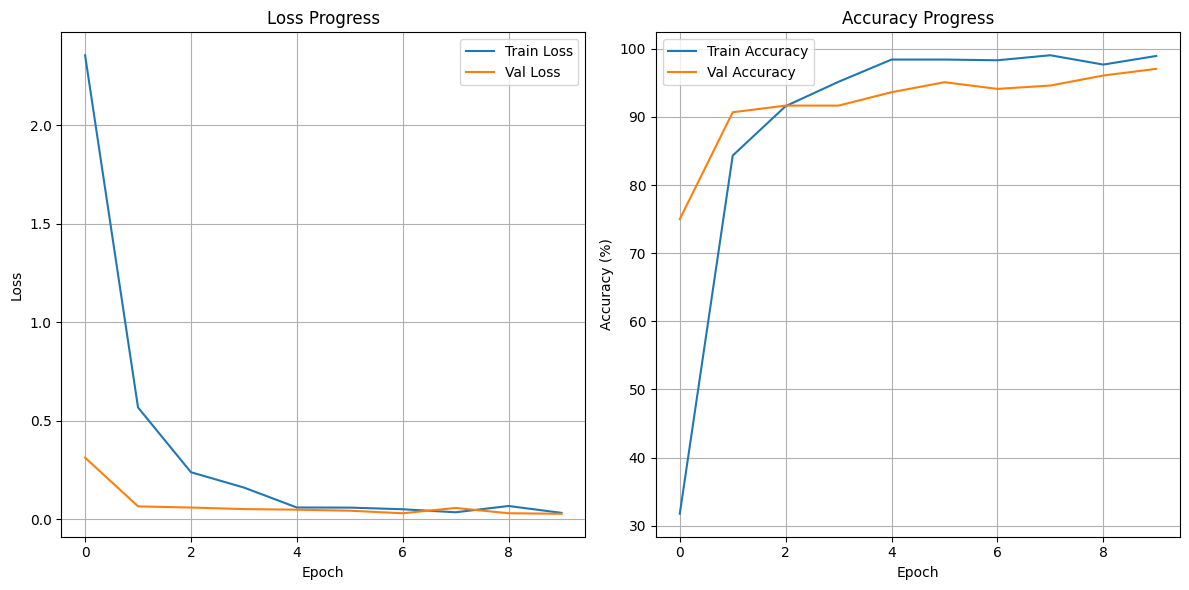

In [ ]:
plt.figure(figsize=(12, 6))

# loss val/train
plt.subplot(1, 2, 1)
plt.plot(train_loss_arr, label='Train Loss')
plt.plot(val_loss_arr, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss Progress')


# accuracy val/train
plt.subplot(1, 2, 2)
plt.plot(train_accuracy_arr, label='Train Accuracy')
plt.plot(val_accuracy_arr, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.title('Accuracy Progress')

plt.tight_layout()
plt.show()


In [92]:
test_acc, test_loss = evaluate(model, test_loader, criterion, device=torch.device("mps"))
print(f"Test Accuracy: {test_acc:.2f}%, Test Loss: {test_loss:.4f}")

Test Accuracy: 92.68%, Test Loss: 2.0036
